In [259]:
import originpro as op
import numpy as np
import matplotlib.pyplot as plt

file = r"H:\FUBerlin\Measurements\PLE\CristianB\20260703_ExtendedDetectorTesting\MiniVersion.opju"
op.open(file)

for obj in op.pages():
    if type(obj).__name__ == "WBook":
        print("\n==========================")
        print("BOOK:", obj.name)
       # for sheet in obj:
       #     print("   PAGE:", sheet.name)


def get_book(book_name):
    for x in op.pages():
        if type(x).__name__ == "WBook" and x.name == book_name:
            return x
    
    raise ValueError(f"Workbook '{book_name}' not found")






BOOK: NIFilt5

BOOK: NIFilt6

BOOK: NIFilt7

BOOK: NIFilt8

BOOK: NIFilt9

BOOK: NIFilt10

BOOK: NIFilt11

BOOK: NIFilt12

BOOK: NIFilt14

BOOK: Water3

BOOK: Water4

BOOK: Water5

BOOK: Water6

BOOK: Water7

BOOK: NoLigh1

BOOK: NoLigh2

BOOK: NIFilt13


In [278]:
NIa = get_book("NIFilt13")

for page in NIa:
    print(page.name)

pages = {page.name: page for page in NIa}

DataC = pages["Data_S1c"]
Data = pages["Data_S1"]
XYZC = pages["XYZ_S1c"]
XYZ = pages["XYZ_S1"]
Meta = pages["Note"]




columns = []

for col in range(XYZC.cols):
    columns.append(XYZC.to_list(col))

xyz_data = np.array(columns).T

print(xyz_data.shape)

emission = xyz_data[:,0]
excitation = xyz_data[:,1]
intensity = xyz_data[:,2]

em_values = np.unique(emission)
exc_values = np.unique(excitation)

# rows = excitation, columns = emission
Z = np.empty((len(exc_values), len(em_values)))

em_index = {v:i for i,v in enumerate(em_values)}
exc_index = {v:i for i,v in enumerate(exc_values)}

for em, exc, inten in zip(emission, excitation, intensity):
    Z[exc_index[exc], em_index[em]] = inten

Graph_S1c
Graph_S1
Contour_S1c
Contour_S1
Data_S1c
Data_S1
XYZ_S1c
XYZ_S1
Note
(22528, 3)


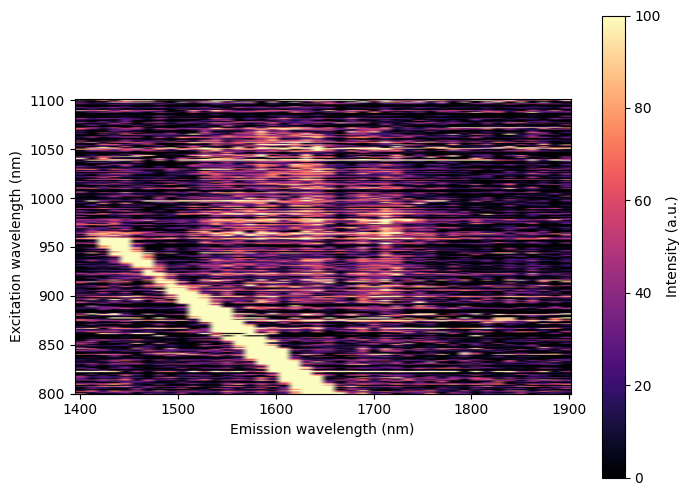

In [281]:
# Plot colormap
plt.figure(figsize=(8,6))

plt.imshow(
    Z,
    extent=[
        em_values.min(),
        em_values.max(),
        exc_values.min(),
        exc_values.max(),
    ],
    #origin="lower",
    #aspect="auto",
    cmap='magma',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [267]:
def extract_PLE_map(book_name):
    book = get_book(book_name)

    pages = {page.name: page for page in book}

    XYZC = pages["XYZ_S1c"]

    columns = []

    for col in range(XYZC.cols):
        columns.append(XYZC.to_list(col))

    xyz_data = np.array(columns).T

    emission = xyz_data[:,0]
    excitation = xyz_data[:,1]
    intensity = xyz_data[:,2]

    em_values = np.unique(emission)
    exc_values = np.unique(excitation)

    Z = np.empty((len(em_values), len(exc_values)))

    em_index = {v:i for i,v in enumerate(em_values)}
    exc_index = {v:i for i,v in enumerate(exc_values)}

    for em, exc, inten in zip(emission, excitation, intensity):
        Z[em_index[em], exc_index[exc]] = inten

    return Z, em_values, exc_values

In [268]:
sample_books = [
    "NIFilt5",
    "NIFilt6",
    "NIFilt7",
    "NIFilt8",
    "NIFilt9",
    "NIFilt10",
    "NIFilt11",
    "NIFilt12",
    "NIFilt13",
    "NIFilt14"
]


maps = []

for name in sample_books:
    Z, em, exc = extract_PLE_map(name)
    maps.append(Z)

sample_average = np.mean(maps, axis=0)


sample_average.shape

(512, 44)

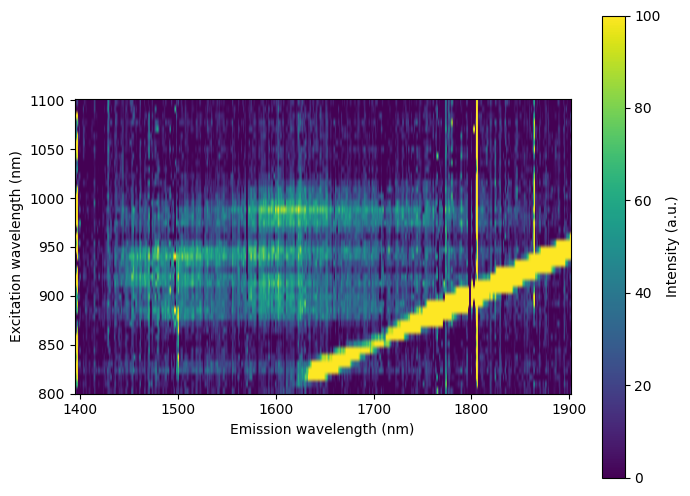

In [285]:
# Plot colormap
plt.figure(figsize=(8,6))

plt.imshow(
    sample_average.T,
    extent=[
        em_values.min(),
        em_values.max(),
        exc_values.min(),
        exc_values.max(),
    ],
    origin="lower",
    #aspect="auto",
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [286]:
water_books = [
    "Water3",
    "Water4",
    "Water5",
    "Water6",
    "Water7",
]


maps = []

for name in water_books:
    Z, em, exc = extract_PLE_map(name)
    maps.append(Z)

water_average = np.mean(maps, axis=0)


water_average.shape

(512, 44)

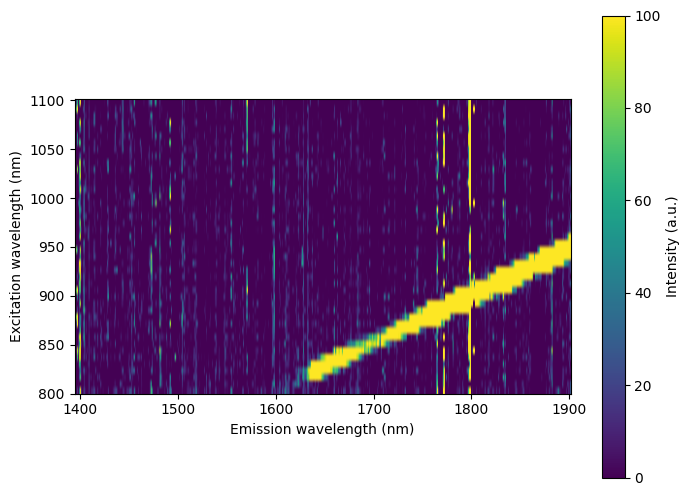

In [287]:
# Plot colormap
plt.figure(figsize=(8,6))

plt.imshow(
    water_average.T,
    extent=[
        em_values.min(),
        em_values.max(),
        exc_values.min(),
        exc_values.max(),
    ],
    origin="lower",
    #aspect="auto",
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()

In [302]:
Z_corr = sample_average - water_average

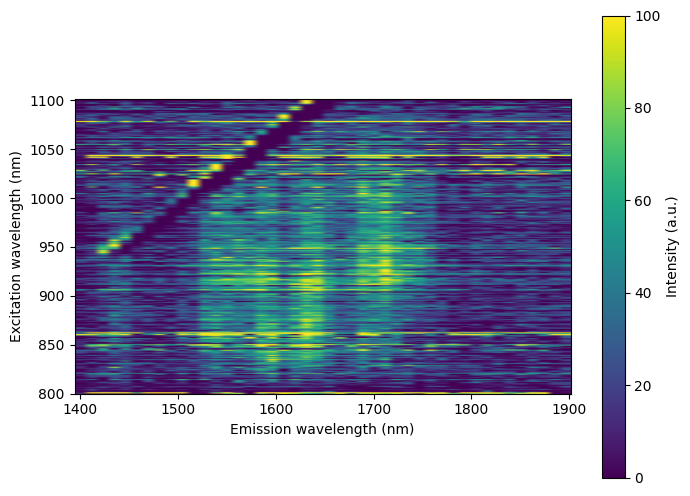

In [303]:
# Plot colormap
plt.figure(figsize=(8,6))

plt.imshow(
    Z_corr,
    extent=[
        em_values.min(),
        em_values.max(),
        exc_values.min(),
        exc_values.max(),
    ],
    origin="lower",
    #aspect="auto",
    cmap='viridis',
    vmin=0,
    vmax=100
)

plt.xlabel("Emission wavelength (nm)")
plt.ylabel("Excitation wavelength (nm)")
plt.colorbar(label="Intensity (a.u.)")
plt.show()